In [56]:
pip install torch torchvision matplotlib numpy

In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [58]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [59]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

subset_size = 20000
dataset = torch.utils.data.Subset(dataset, range(subset_size))

dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

In [60]:
latent_dim = 100
epochs = 8

In [61]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

In [62]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(

            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512, 1, 4, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1)

In [63]:
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

generator.apply(weights_init)
discriminator.apply(weights_init)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1))
    (12): Sigmoid()
  )
)

In [64]:
criterion = nn.BCELoss()

optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001)
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)

In [65]:
for epoch in range(epochs):
    for real_images, _ in dataloader:

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # ---- Train Discriminator ----
        optimizer_D.zero_grad()

        outputs_real = discriminator(real_images)
        real_labels = torch.ones_like(outputs_real).to(device) * 0.9
        loss_real = criterion(outputs_real, real_labels)

        noise = torch.randn(batch_size, latent_dim, 1, 1).to(device)
        fake_images = generator(noise)

        outputs_fake = discriminator(fake_images.detach())
        fake_labels = torch.zeros_like(outputs_fake).to(device)
        loss_fake = criterion(outputs_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        # ---- Train Generator MORE ----
        for _ in range(3):
            optimizer_G.zero_grad()

            noise = torch.randn(batch_size, latent_dim, 1, 1).to(device)
            fake_images = generator(noise)

            outputs = discriminator(fake_images)
            real_labels = torch.ones_like(outputs).to(device)

            loss_G = criterion(outputs, real_labels)
            loss_G.backward()
            optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] | Loss D: {loss_D.item():.4f} | Loss G: {loss_G.item():.4f}")

Epoch [1/8] | Loss D: 3.4696 | Loss G: 0.6146
Epoch [2/8] | Loss D: 2.0216 | Loss G: 0.5570
Epoch [3/8] | Loss D: 2.1236 | Loss G: 0.5601
Epoch [4/8] | Loss D: 1.7155 | Loss G: 0.6735
Epoch [5/8] | Loss D: 1.8371 | Loss G: 0.7575
Epoch [6/8] | Loss D: 1.5373 | Loss G: 0.8055
Epoch [7/8] | Loss D: 1.6829 | Loss G: 0.7169
Epoch [8/8] | Loss D: 1.5461 | Loss G: 0.9205


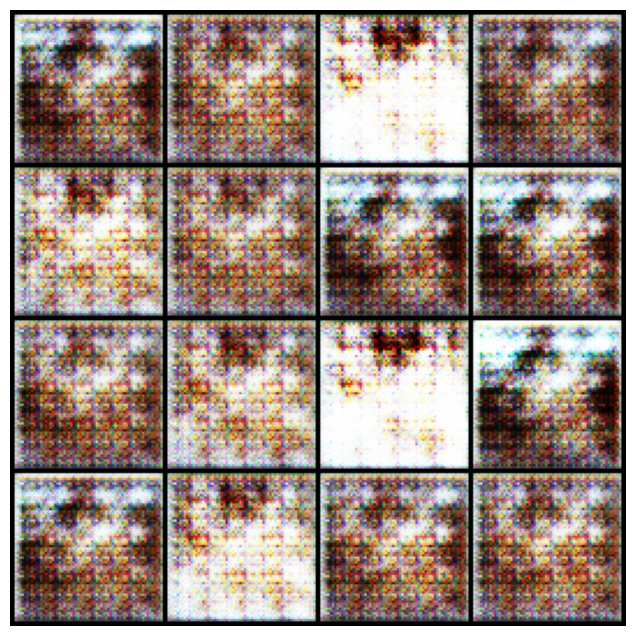

In [66]:
generator.eval()

noise = torch.randn(16, latent_dim, 1, 1).to(device)
fake_images = generator(noise).detach().cpu()

grid = torchvision.utils.make_grid(fake_images, nrow=4, normalize=True)

plt.figure(figsize=(8,8))
plt.imshow(np.transpose(grid, (1,2,0)))
plt.axis('off')
plt.show()

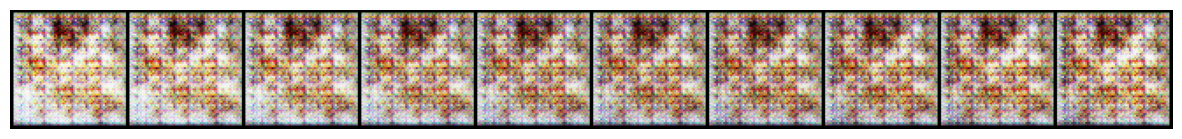

In [67]:
z1 = torch.randn(1, latent_dim, 1, 1).to(device)
z2 = torch.randn(1, latent_dim, 1, 1).to(device)

images = []
for alpha in np.linspace(0, 1, 10):
    z = (1 - alpha) * z1 + alpha * z2
    img = generator(z).detach().cpu()
    images.append(img)

images = torch.cat(images)

grid = torchvision.utils.make_grid(images, nrow=10, normalize=True)

plt.figure(figsize=(15,3))
plt.imshow(np.transpose(grid, (1,2,0)))
plt.axis('off')
plt.show()